<a href="https://colab.research.google.com/github/jhhlim/LLMFundamentals/blob/main/Jason_Lim_hw_3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/jhhlim/LLMFundamentals/blob/cursor/hw-3-sentiment-topic-a051/Jason_Lim_hw_3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Class 3b — LLM Fundamentals (UCSC Extension)
# Homework 3b: Text Clustering and Topic Modeling

Jason Lim  

## Goal
Discover latent themes in unstructured free-text using the Class 3b / Hands-On LLM Ch. 5 pipeline:

1. **Embed** documents  
2. **Reduce** dimensions with **UMAP**  
3. **Cluster** with **HDBSCAN**  
4. Turn clusters into interpretable **topics** with **BERTopic** (c-TF-IDF keywords)

Also includes the class support warm-up: **Palmer Penguins + UMAP**.

## Dataset
**Hugging Face — `billingsmoore/text-clustering-example-data`**  
https://huggingface.co/datasets/billingsmoore/text-clustering-example-data

- 925 English sentences with a broad topic descriptor  
- Same dataset used in the class UMAP support notebook  
- Ideal size for Colab topic-modeling homework

## References
- Class support notebook: Read dataset / Penguins / UMAP  
- Class 3b / Hands-On LLM Ch. 5: embeddings → UMAP → HDBSCAN → BERTopic


### Install packages (Colab)

💡 **NOTE**: A GPU helps for sentence embeddings, but this homework dataset is small enough to run on CPU.


In [2]:
%%capture
!pip install -q datasets umap-learn hdbscan bertopic sentence-transformers pandas matplotlib seaborn scikit-learn wordcloud


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
%matplotlib inline


## Part A — Palmer Penguins UMAP warm-up (class support notebook)

Practice UMAP on a small numeric dataset before applying the same idea to text embeddings.


In [3]:
penguins = pd.read_csv(
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/"
    "c19a904462482430170bfe2c718775ddb7dbb885/inst/extdata/penguins.csv"
)
penguins = penguins.dropna()
print("Shape after dropna:", penguins.shape)
print(penguins.species.value_counts())
penguins.head()


Shape after dropna: (333, 8)
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


2D embedding shape: (333, 2)


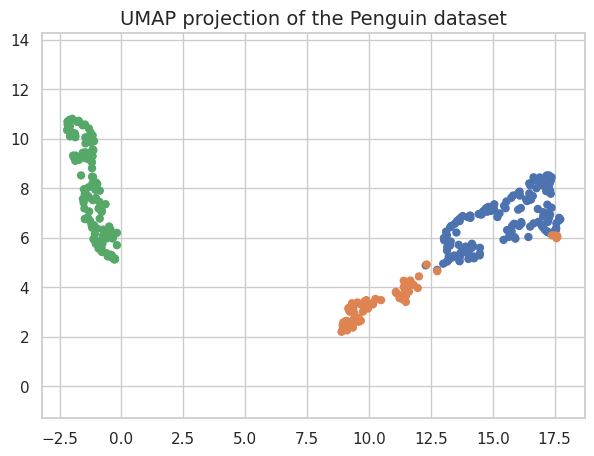

In [4]:
import umap

# Standard scaling: bill length/depth, flipper length, and body mass are on different scales.
penguin_data = penguins[
    ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
].values
scaled_penguin_data = StandardScaler().fit_transform(penguin_data)

reducer_2 = umap.UMAP(n_components=2, random_state=42)
embedding_2 = reducer_2.fit_transform(scaled_penguin_data)
print("2D embedding shape:", embedding_2.shape)

plt.figure(figsize=(7, 5))
plt.scatter(
    embedding_2[:, 0],
    embedding_2[:, 1],
    c=[
        sns.color_palette()[x]
        for x in penguins.species.map({"Adelie": 0, "Chinstrap": 1, "Gentoo": 2})
    ],
    s=25,
)
plt.gca().set_aspect("equal", "datalim")
plt.title("UMAP projection of the Penguin dataset", fontsize=14)
plt.show()


## Part B — Load the text clustering dataset

Class support notebook pattern:
```python
from datasets import load_dataset
dataset = load_dataset("billingsmoore/text-clustering-example-data")["train"]
```


In [5]:
from datasets import load_dataset

dataset = load_dataset("billingsmoore/text-clustering-example-data")["train"]
df = dataset.to_pandas()
texts = df["text"].tolist()
true_topics = df["topic"].tolist()

print("Shape:", df.shape)
print("\nTopic counts:")
print(df["topic"].value_counts())
df.head()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/2.02k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 39.1kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/925 [00:00<?, ? examples/s]

Shape: (925, 2)

Topic counts:
topic
cars and trucks              98
cats and dogs                93
religion and spirituality    93
yoga and meditation          93
cooking and cuisine          93
apples and oranges           92
plants and gardening         92
condos and houses            91
ducks and songbirds          90
football and basketball      90
Name: count, dtype: int64


,text,topic
0,The pickup truck was loaded with heavy constru...,cars and trucks
1,The sports car accelerated down the highway at...,cars and trucks
2,Trucks are commonly used to transport goods ac...,cars and trucks
3,The electric car is becoming more popular due ...,cars and trucks
4,SUVs are great for families who need extra spa...,cars and trucks


## Part C — Common pipeline for text clustering (Class 3b / Ch. 5)

### 1) Embed documents with a sentence transformer


In [6]:
from sentence_transformers import SentenceTransformer

# Compact, fast embedding model (works well on Colab CPU/GPU for ~1k docs)
embedding_model = SentenceTransformer("thenlper/gte-small")
embeddings = embedding_model.encode(texts, show_progress_bar=True)
print("Embedding shape:", embeddings.shape)


modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/68.1k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 66.7MB            

...

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/29 [00:00<?, ?it/s]

Embedding shape: (925, 384)


### 2) Reduce dimensionality with UMAP (for clustering)

In [7]:
from umap import UMAP

# Reduce high-dim embeddings before density clustering (Ch. 5 pattern)
umap_model = UMAP(n_components=5, min_dist=0.0, metric="cosine", random_state=42)
reduced_embeddings = umap_model.fit_transform(embeddings)
print("Reduced embedding shape:", reduced_embeddings.shape)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Reduced embedding shape: (925, 5)


### 3) Cluster with HDBSCAN

In [8]:
from hdbscan import HDBSCAN

# Smaller min_cluster_size because this homework corpus is ~925 docs (not ArXiv-scale)
hdbscan_model = HDBSCAN(
    min_cluster_size=15,
    metric="euclidean",
    cluster_selection_method="eom",
)
clusters = hdbscan_model.fit_predict(reduced_embeddings)

n_clusters = len(set(clusters) - {-1})
n_outliers = int((clusters == -1).sum())
print("Clusters found:", n_clusters)
print("Outliers (label -1):", n_outliers)
print(pd.Series(clusters).value_counts().sort_index().head(20))


Clusters found: 15
Outliers (label -1): 4
-1       4
 0      98
 1      45
 2      45
 3      48
 4      45
 5      46
 6      54
 7      83
 8      91
 9      89
 10     47
 11     46
 12    142
 13     16
 14     26
Name: count, dtype: int64


### Inspect a few documents from cluster 0

In [9]:
cluster_id = 0
idxs = np.where(clusters == cluster_id)[0][:5]
print(f"Sample docs from cluster {cluster_id}:\n")
for i in idxs:
    print("-", texts[i], "| true topic:", true_topics[i])


Sample docs from cluster 0:

- The pickup truck was loaded with heavy construction materials. | true topic: cars and trucks
- The sports car accelerated down the highway at an incredible speed. | true topic: cars and trucks
- Trucks are commonly used to transport goods across long distances. | true topic: cars and trucks
- The electric car is becoming more popular due to its eco-friendliness. | true topic: cars and trucks
- SUVs are great for families who need extra space for passengers and cargo. | true topic: cars and trucks


### 2D UMAP visualization of clusters

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


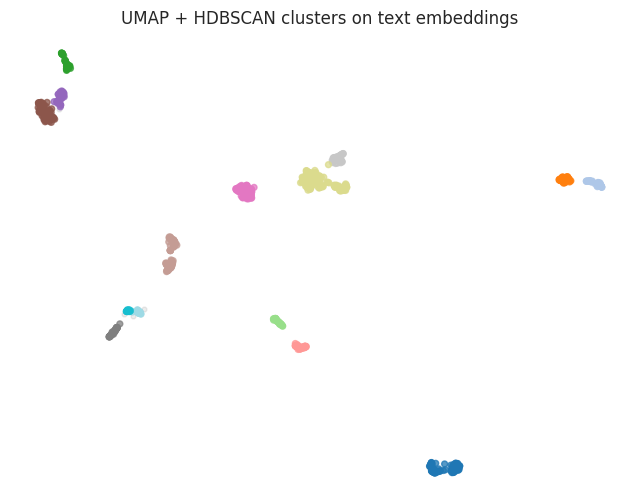

In [10]:
# Separate 2D reduction for plotting (same idea as the Ch. 5 notebook)
plot_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric="cosine", random_state=42
).fit_transform(embeddings)

plot_df = pd.DataFrame(plot_embeddings, columns=["x", "y"])
plot_df["cluster"] = clusters.astype(str)
plot_df["true_topic"] = true_topics
plot_df["text"] = texts

clusters_df = plot_df[plot_df["cluster"] != "-1"]
outliers_df = plot_df[plot_df["cluster"] == "-1"]

plt.figure(figsize=(8, 6))
plt.scatter(outliers_df.x, outliers_df.y, alpha=0.15, s=12, c="grey", label="outlier")
plt.scatter(
    clusters_df.x,
    clusters_df.y,
    c=clusters_df.cluster.astype(int),
    alpha=0.75,
    s=18,
    cmap="tab20",
)
plt.axis("off")
plt.title("UMAP + HDBSCAN clusters on text embeddings")
plt.show()


## Part D — From clustering to topic modeling with BERTopic

BERTopic wraps the same embedding → UMAP → HDBSCAN stack and adds **c-TF-IDF** topic keywords.


In [11]:
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True,
)
topics, probs = topic_model.fit_transform(texts, embeddings)

topic_info = topic_model.get_topic_info()
print(topic_info.head(12))
topic_info


2026-07-28 05:47:25,694 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-07-28 05:47:28,684 - BERTopic - Dimensionality - Completed ✓
2026-07-28 05:47:28,686 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-07-28 05:47:28,709 - BERTopic - Cluster - Completed ✓
2026-07-28 05:47:28,714 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-07-28 05:47:28,762 - BERTopic - Representation - Completed ✓


    Topic  Count                              Name  \
0      -1      4       -1_tzu_huskies_hair_chasing   
1       0    142        0_apple_and_flavor_cooking   
2       1     98            1_trucks_are_car_truck   
3       2     91          2_duck_the_feathers_song   
4       3     89     3_plants_garden_can_gardening   
5       4     83           4_spiritual_of_many_the   
6       5     54          5_meditation_can_help_of   
7       6     48              6_yoga_pose_body_and   
8       7     47             7_cat_kitten_the_coat   
9       8     46  8_condo_condos_residents_private   
10      9     46        9_orange_juice_oranges_was   
11     10     45  10_football_the_quarterback_game   

                                       Representation  \
0   [tzu, huskies, hair, chasing, topknot, tied, s...   
1   [apple, and, flavor, cooking, for, apples, wit...   
2   [trucks, are, car, truck, for, electric, cars,...   
3   [duck, the, feathers, song, ducklings, its, ma...   
4   [plants,

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4,-1_tzu_huskies_hair_chasing,"[tzu, huskies, hair, chasing, topknot, tied, s...",[Huskies are known for their stunning blue eye...
1,0,142,0_apple_and_flavor_cooking,"[apple, and, flavor, cooking, for, apples, wit...",[The apple's crisp texture made it perfect for...
2,1,98,1_trucks_are_car_truck,"[trucks, are, car, truck, for, electric, cars,...",[Trucks are commonly used to transport goods a...
3,2,91,2_duck_the_feathers_song,"[duck, the, feathers, song, ducklings, its, ma...",[The mallard duck swam gracefully across the c...
4,3,89,3_plants_garden_can_gardening,"[plants, garden, can, gardening, your, and, li...",[Gardening gloves protect your hands while wor...
5,4,83,4_spiritual_of_many_the,"[spiritual, of, many, the, in, is, holy, relig...",[The concept of karma is central to many spiri...
6,5,54,5_meditation_can_help_of,"[meditation, can, help, of, and, sense, awaren...",[Meditation can help increase focus and awaren...
7,6,48,6_yoga_pose_body_and,"[yoga, pose, body, and, the, poses, strengthen...",[The child’s pose in yoga provides a gentle st...
8,7,47,7_cat_kitten_the_coat,"[cat, kitten, the, coat, fur, it, persian, cat...",[The Abyssinian cat's short coat gleamed in th...
9,8,46,8_condo_condos_residents_private,"[condo, condos, residents, private, the, views...",[The condo has a communal lounge that resident...


### Top keywords for a few topics

In [12]:
# Show top words for the largest non-outlier topics
non_outlier = topic_info[topic_info.Topic != -1].head(8)
for topic_num in non_outlier.Topic.tolist():
    words = topic_model.get_topic(topic_num)
    top = ", ".join([w for w, _ in words[:8]])
    print(f"Topic {topic_num}: {top}")


Topic 0: apple, and, flavor, cooking, for, apples, with, is
Topic 1: trucks, are, car, truck, for, electric, cars, the
Topic 2: duck, the, feathers, song, ducklings, its, mallard, in
Topic 3: plants, garden, can, gardening, your, and, like, soil
Topic 4: spiritual, of, many, the, in, is, holy, religious
Topic 5: meditation, can, help, of, and, sense, awareness, create
Topic 6: yoga, pose, body, and, the, poses, strengthens, opens
Topic 7: cat, kitten, the, coat, fur, it, persian, cats


In [13]:
# Compare discovered topics vs the dataset's provided topic labels (qualitative check)
cmp = pd.DataFrame({"bertopic": topics, "true_topic": true_topics})
print("Documents per BERTopic topic (top):")
print(cmp["bertopic"].value_counts().head(10))
print("\nCrosstab (BERTopic topic vs true label):")
ct = pd.crosstab(cmp["bertopic"], cmp["true_topic"])
ct.head(10)


Documents per BERTopic topic (top):
bertopic
0    142
1     98
2     91
3     89
4     83
5     54
6     48
7     47
8     46
9     46
Name: count, dtype: int64

Crosstab (BERTopic topic vs true label):


true_topic,apples and oranges,cars and trucks,cats and dogs,condos and houses,cooking and cuisine,ducks and songbirds,football and basketball,plants and gardening,religion and spirituality,yoga and meditation
bertopic,,,,,,,,,,
-1,0,0,3,0,0,0,0,0,1,0
0,46,0,0,0,93,0,0,3,0,0
1,0,98,0,0,0,0,0,0,0,0
2,0,0,1,0,0,90,0,0,0,0
3,0,0,0,0,0,0,0,89,0,0
4,0,0,0,0,0,0,0,0,82,1
5,0,0,0,0,0,0,0,0,9,45
6,0,0,0,0,0,0,0,0,1,47
7,0,0,47,0,0,0,0,0,0,0


### Topic visualizations

In [14]:
# BERTopic charts (HTML widgets in Colab / Jupyter)
fig_bar = topic_model.visualize_barchart(top_n_topics=8)
fig_bar.show()

fig_docs = topic_model.visualize_documents(
    texts,
    reduced_embeddings=plot_embeddings,
    width=1000,
    hide_annotations=True,
)
fig_docs.update_layout(font=dict(size=14))
fig_docs.show()


## Learnings / analysis notes

1. **Penguins → text:** UMAP is the same idea on different inputs, numeric penguin measurements, then high-dimensional sentence embeddings.
2. **Pipeline:** Embeddings capture meaning → UMAP makes neighborhoods denser / lower-dim → HDBSCAN finds clusters without forcing a fixed `k`.
3. **Topic modeling vs clustering:** Clustering only groups docs; BERTopic adds c-TF-IDF keywords so each cluster becomes an interpretable topic.
4. **Dataset:** The HF clustering example set is small and labeled by broad topic, so we can visually check whether discovered clusters align with true themes.
5. **Product-review extension:** The same notebook pipeline can be pointed at UCI Amazon/Yelp review sentences for product-specific themes (battery, sound quality, service, etc.).
